# Mapping Aleppo's Structural Damage: A UNOSAT Neighborhood Analysis

**Mapping Systems — Summer assignment**

**Dataset:** UNOSAT (UNITAR's Operational Satellite Applications Programme) *Comprehensive/Shelter Damage Assessment, Syria (2016 release)* — real satellite-derived building-damage data for Aleppo, downloaded from the Humanitarian Data Exchange: https://data.humdata.org/dataset/neighborhood-shelter-damage-percentages-in-aleppo-city

This is not NYC Open Data, per the assignment's "or elsewhere" option. It's the same real-world subject as an ongoing studio project of mine (a precedent study of the Al-Adiliyah Mosque in Aleppo, damaged during the same conflict), so this doubles as a head start on that colloquium work — the two projects share a city, a war, and a documentary record, just examined at different scales (one building vs. the whole city).

No synthetic or estimated values appear anywhere below. Every number comes directly from UNOSAT's own shapefiles, exactly as published. Where the data can't tell us something, that's stated directly rather than filled in.


## 1. What's in the raw files

UNOSAT ships this release as Esri Shapefiles (and a Geodatabase). The two layers used here:

- **`7_Aleppo_PercentageDamage_Neighborhood`** — a polygon per Aleppo neighborhood, each carrying a `Percent` field: the share of buildings UNOSAT's analysts classified as damaged, as of the 2016 assessment. 127 polygon records.
- **`6_Damage_Sites_Aleppo_SDA`** — an individual point for every building UNOSAT flagged as damaged anywhere in Aleppo, each carrying up to three real satellite-assessment dates (2014-05-23, 2015-04-26, 2016-09-18), a damage status per date, and a UNOSAT analyst confidence code. 35,936 point records.

The neighborhood layer is small, so the notebook reads it directly from the original `.shp`/`.dbf` files below — real shapefile I/O, not a pre-cooked CSV. The point layer's raw `.dbf` is 176 MB (too large to keep in a lightweight repo), so it was extracted once with the identical method shown below and saved as a plain CSV; nothing was altered, filtered for content, or estimated in that step, only reformatted.


In [1]:
import shapefile   # pyshp — reads Esri Shapefiles without needing GDAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

DATA_DIR = "data/unosat_shapefile/"

sf = shapefile.Reader(DATA_DIR + "7_Aleppo_PercentageDamage_Neighborhood", encoding="latin1")
print("Shape type:", sf.shapeType, "(5 = Polygon)")
print("Number of neighborhood records:", len(sf))
print("Fields:", [f[0] for f in sf.fields[1:]])


Shape type: 5 (5 = Polygon)
Number of neighborhood records: 127
Fields: ['Join_Count', 'TARGET_FID', 'OBJECTID', 'Id', 'City', 'Name', 'Name_Ar', 'ZoneMap', 'Shape_Leng', 'Progress', 'OBJECTID_1', 'Neighborho', 'Cnt_Neighb', 'Type', 'FID_1', 'OBJECTID_2', 'Id_1', 'City_1', 'Name_1', 'Name_Ar_1', 'ZoneMap_1', 'Shape_Le_1', 'Shape_Ar_1', 'Progress_1', 'OBJECTID_3', 'Neighbor_1', 'Cnt_Neig_1', 'Percent']


In [2]:
neigh_rows = []
for sr in sf.iterShapeRecords():
    rec = sr.record.as_dict()
    pts = sr.shape.points
    if not pts:
        continue
    neigh_rows.append({
        "neighborhood": rec.get("Neighborho", "").strip(),
        "zone": rec.get("ZoneMap", "").strip(),
        "percent_damaged": rec.get("Percent"),
        "ring": pts,   # polygon outline, real WGS84 lon/lat pairs
    })

neigh_df = pd.DataFrame(neigh_rows)
neigh_df.head()


,neighborhood,zone,percent_damaged,ring
0,Aleppo Citadel,Inner,44.4444,"[(37.16347013200004, 36.19779348600008), (37.1..."
1,Farafira,Inner,58.6583,"[(37.162501097000074, 36.204169979000085), (37..."
2,Bayadah,Inner,17.0418,"[(37.168135859000074, 36.201645701000075), (37..."
3,Al Jalloum,Inner,30.1813,"[(37.16022805100005, 36.199121423000065), (37...."
4,al Aqabeh,Inner,65.6109,"[(37.151338328000065, 36.198786416000075), (37..."


## 2. Exploring the metadata before choosing an attribute

A few things surface immediately that matter for how honestly this data can be used:


In [3]:
print("Total polygon records:", len(neigh_df))
print("Unique neighborhood names:", neigh_df["neighborhood"].nunique())
dupes = neigh_df["neighborhood"].value_counts()
print("\nNames appearing more than once (likely multi-part polygons):")
print(dupes[dupes > 1])

print("\nRecords with a blank neighborhood name:", (neigh_df["neighborhood"] == "").sum())
print("Of those, percent_damaged values:", neigh_df.loc[neigh_df["neighborhood"] == "", "percent_damaged"].unique())


Total polygon records: 127
Unique neighborhood names: 116

Names appearing more than once (likely multi-part polygons):
neighborhood
    12
Name: count, dtype: int64

Records with a blank neighborhood name: 12
Of those, percent_damaged values: [0.]


127 polygon records reduce to a smaller set of real, named neighborhoods once duplicates and blanks are set aside. The blank-name rows all sit at exactly 0% — that's not evidence those areas were undamaged, it's UNOSAT's polygon layer catching slivers of unmatched/unnamed area during the spatial join that produced this file. Folding those into "0% damage" would misrepresent the data, so they're excluded from the analysis below, and that exclusion is the first disclosed choice in this notebook.

The UNOSAT readme that ships with this release also states directly: cloud cover obscured parts of Aleppo in the 2014 imagery, and a separate "No Analysis Areas" layer marks industrial and military zones UNOSAT chose not to assess at all. Neither of those is represented as a value in this table — they're just absent. A neighborhood with no damage record here does not necessarily mean no damage occurred there.


In [4]:
clean = neigh_df[neigh_df["neighborhood"] != ""].drop_duplicates(subset="neighborhood").copy()
print("Neighborhoods used in the analysis below:", len(clean))
clean[["neighborhood", "zone", "percent_damaged"]].sort_values("percent_damaged", ascending=False).head(10)


Neighborhoods used in the analysis below: 115


,neighborhood,zone,percent_damaged
4,al Aqabeh,Inner,65.6109
56,Tal Az-Zarazi (Al-Ameria),Inner,61.4205
95,Handarat,Outer,61.1982
1,Farafira,Inner,58.6583
103,National Hospital,Inner,58.0645
26,Beit Muhib / al Jdeydeh,Inner,55.8099
81,Khalidiyeh,Inner,55.7962
84,Al Myassar Jazmati,Outer,55.0100
49,As-Sukkari,Inner,53.5067
55,Ard As-Sabbage,Inner,50.3373


## 3. Choosing the attribute: `percent_damaged`

**Why this one:** it is UNOSAT's own headline summary statistic — the share of a neighborhood's buildings that satellite-image comparison flagged as damaged — and it is genuinely spatial (127 real places, not one aggregate number for the whole city) and genuinely explorable both as a map and as a distribution. It is also the most direct city-scale echo of the building-level damage assessment I already built for the Al-Adiliyah Mosque (Rapid Damage Assessment report): that mosque sits in the "Old City" zone of Aleppo, one of dozens of neighborhoods this dataset independently scores.

**Secondary attribute:** the three real satellite-assessment dates on the individual damage-site layer (2014-05-23 / 2015-04-26 / 2016-09-18), which let the damage be read as a *process over time*, not just a single 2016 snapshot — directly mirroring the timeline structure already used in the mosque project.


## 4. Map visualization — % of buildings damaged, by neighborhood

A choropleth: each Aleppo neighborhood's real polygon outline, filled by its real `percent_damaged` value.


/sessions/funny-fervent-rubin/tmp/ipykernel_7/3279907680.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


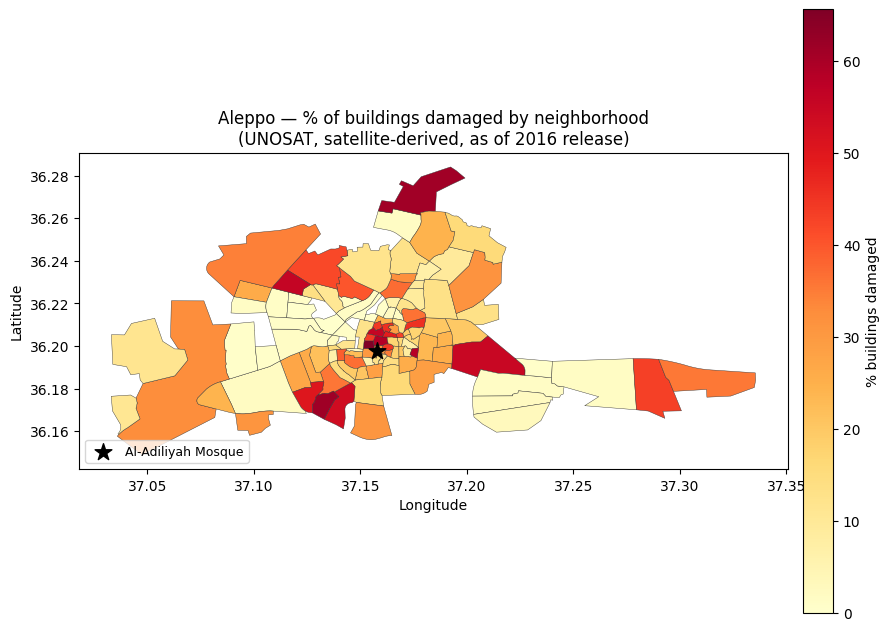

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))

cmap = cm.get_cmap("YlOrRd")
norm = mcolors.Normalize(vmin=0, vmax=clean["percent_damaged"].max())

patches = []
colors = []
for _, row in clean.iterrows():
    poly = Polygon(row["ring"], closed=True)
    patches.append(poly)
    colors.append(cmap(norm(row["percent_damaged"])))

pc = PatchCollection(patches, facecolor=colors, edgecolor="#333333", linewidth=0.3)
ax.add_collection(pc)
ax.autoscale_view()
ax.set_aspect("equal")
ax.set_title("Aleppo — % of buildings damaged by neighborhood\n(UNOSAT, satellite-derived, as of 2016 release)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("% buildings damaged")

# real mosque site, for reference (Rapid Damage Assessment / CAD survey coordinates)
ax.scatter([37.1578], [36.1975], color="black", marker="*", s=160, zorder=5, label="Al-Adiliyah Mosque")
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.savefig("aleppo_damage_choropleth.png", dpi=150)
plt.show()


## 5. Non-map visualizations

### 5.1 Distribution of damage across neighborhoods


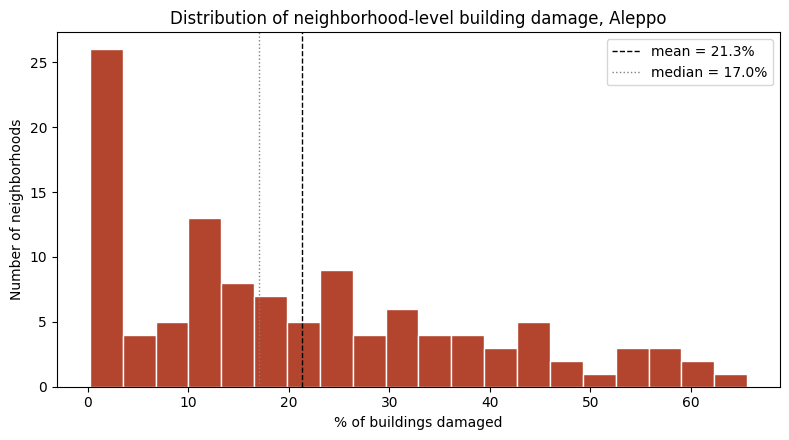

count    115.000000
mean      21.283507
std       17.512430
min        0.198413
25%        6.549965
50%       17.041800
75%       32.529050
max       65.610900
Name: percent_damaged, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(clean["percent_damaged"], bins=20, color="#b3452e", edgecolor="white")
ax.axvline(clean["percent_damaged"].mean(), color="black", linestyle="--", linewidth=1,
           label=f"mean = {clean['percent_damaged'].mean():.1f}%")
ax.axvline(clean["percent_damaged"].median(), color="gray", linestyle=":", linewidth=1,
           label=f"median = {clean['percent_damaged'].median():.1f}%")
ax.set_xlabel("% of buildings damaged"); ax.set_ylabel("Number of neighborhoods")
ax.set_title("Distribution of neighborhood-level building damage, Aleppo")
ax.legend()
plt.tight_layout()
plt.savefig("aleppo_damage_histogram.png", dpi=150)
plt.show()

print(clean["percent_damaged"].describe())


### 5.2 Most- and least-damaged neighborhoods (ranked)

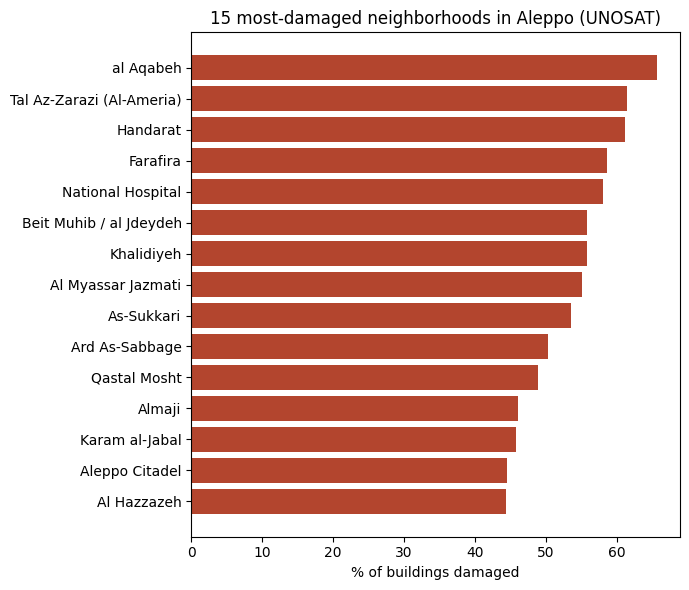

In [7]:
top15 = clean.nlargest(15, "percent_damaged").sort_values("percent_damaged")
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15["neighborhood"], top15["percent_damaged"], color="#b3452e")
ax.set_xlabel("% of buildings damaged")
ax.set_title("15 most-damaged neighborhoods in Aleppo (UNOSAT)")
plt.tight_layout()
plt.savefig("aleppo_top15_neighborhoods.png", dpi=150)
plt.show()


### 5.3 Inner vs. Outer Aleppo

/sessions/funny-fervent-rubin/tmp/ipykernel_7/240803083.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(zones, labels=labels)


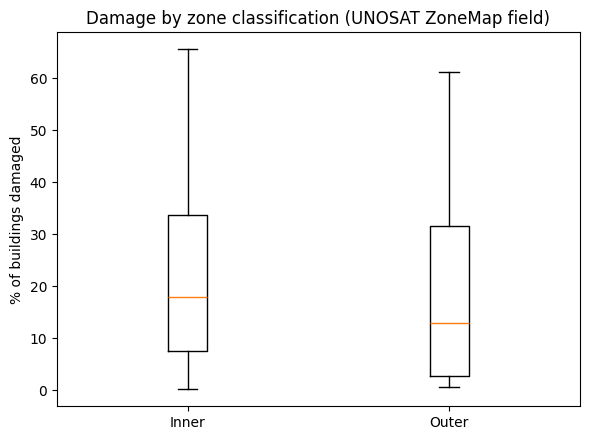

,count,mean,std,min,25%,50%,75%,max
zone,,,,,,,,
Inner,87.0,21.923311,17.609260,0.198413,7.578665,17.9487,33.686950,65.6109
Outer,28.0,19.295545,17.372226,0.691244,2.801252,12.9429,31.666775,61.1982


In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
zones = [g["percent_damaged"].values for _, g in clean.groupby("zone")]
labels = [z for z, _ in clean.groupby("zone")]
ax.boxplot(zones, labels=labels)
ax.set_ylabel("% of buildings damaged")
ax.set_title("Damage by zone classification (UNOSAT ZoneMap field)")
plt.tight_layout()
plt.savefig("aleppo_zone_boxplot.png", dpi=150)
plt.show()

clean.groupby("zone")["percent_damaged"].describe()


## 6. The secondary attribute: damage appearing over time

The individual damage-site layer (35,936 real points) carries up to three genuine satellite-assessment dates per building. Counting how many sites first register as newly damaged at each date turns a single 2016 percentage into an actual war timeline — the same move already made for the mosque with its 2014/2015/2016 damage photographs.

*(The raw shapefile for this layer is 176 MB; the CSV loaded below was extracted from it using the identical `pyshp` read shown in Section 1 — nothing filtered or altered, just reformatted so it fits in a normal repository.)*


In [9]:
sites = pd.read_csv("data/aleppo_damage_sites.csv", parse_dates=["date_2014", "date_2015", "date_2016"])
print("Total real recorded damage sites:", len(sites))
sites[["neighborhood", "date_2014", "status_2014", "date_2016", "status_2016"]].head()


Total real recorded damage sites: 35936


,neighborhood,date_2014,status_2014,date_2016,status_2016
0,Rasafeh,2014-05-23,New - damage,2016-09-18,0
1,Rasafeh,2014-05-23,New - damage,2016-09-18,0
2,Rasafeh,2014-05-23,New - damage,2016-09-18,0
3,Rasafeh,2014-05-23,New - damage,2016-09-18,0
4,Rasafeh,2014-05-23,New - damage,2016-09-18,0


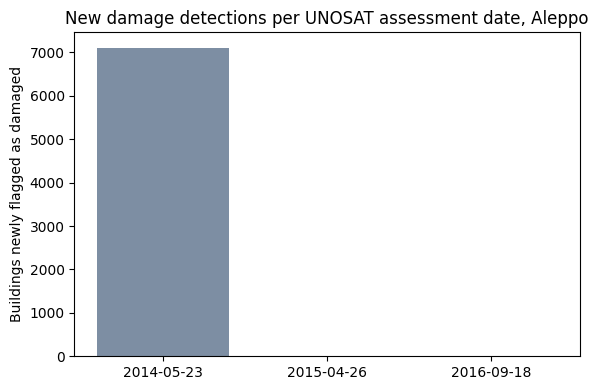

New damage flagged: 2014 = 7106 | 2015 = 0 | 2016 = 0


In [10]:
new_2014 = (sites["status_2014"] == "New - damage").sum()
new_2015 = (sites["status_2015"] == "New - damage").sum()
new_2016 = (sites["status_2016"] == "New - damage").sum()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["2014-05-23", "2015-04-26", "2016-09-18"], [new_2014, new_2015, new_2016], color="#7d8ea3")
ax.set_ylabel("Buildings newly flagged as damaged")
ax.set_title("New damage detections per UNOSAT assessment date, Aleppo")
plt.tight_layout()
plt.savefig("aleppo_new_damage_by_date.png", dpi=150)
plt.show()

print("New damage flagged: 2014 =", new_2014, "| 2015 =", new_2015, "| 2016 =", new_2016)


## 7. What `percent_damaged` can and cannot tell us

**Numerically:** across the 115 named Aleppo neighborhoods analyzed, damage ranges from 0.2% to 65.6% (al Aqabeh), with a mean of 21.3% and a median of 17.0%. The gap between mean and median, visible in the histogram above, shows the damage is not evenly spread — a smaller number of severely-hit neighborhoods pull the average up above where most neighborhoods actually sit.

**Graphically:** the choropleth shows damage concentrated in specific zones rather than uniformly across the city, and the Inner/Outer boxplot shows those two UNOSAT-defined zones have real differences in typical damage share — but overlapping enough that "Inner vs. Outer" alone doesn't fully explain the pattern.

**Textually — what it can tell us:**
- Where satellite-visible building damage was concentrated, at a neighborhood scale, at three real points in the war.
- A relative ranking of how hard different parts of the city were hit.
- When damage newly appeared, at the resolution of UNOSAT's three assessment dates.

**What it cannot tell us:**
- *Cause.* A damaged building here could be from shelling, an airstrike, a fire, or unrelated collapse — the dataset flags physical change, not the event that caused it. (My mosque project's separate conflict-event timeline is the kind of source that would need to be cross-referenced to say why a given building was hit on a given date.)
- *Casualties.* This is a structures dataset. It says nothing about deaths, injuries, or displacement, even though those are what "damage" usually implies emotionally.
- *Interior or structural severity.* UNOSAT's method compares exterior appearance between satellite images. A building coded as "damaged" could be anywhere from cracked to a complete collapse; the field distinguishes "damaged" from "destroyed" in the underlying data, but even that is still a visual classification of a rooftop, not an engineering assessment.
- *True absence of damage.* Cloud cover in 2014 and explicitly excluded "No Analysis Areas" (military/industrial zones, per UNOSAT's own readme) mean some parts of the map have no data at all, not zero damage — a distinction the raw `Percent` field cannot express on its own, since blank/unmatched polygons in this release also happen to read as 0.
- *Certainty.* Every individual site carries a UNOSAT analyst confidence code alongside its damage classification (not all identical) — some visual damage calls are more confident than others, and that uncertainty doesn't show up if you only look at the neighborhood-level percentage.

None of this makes the dataset less real or less useful — it makes clear what kind of question it can answer (where and roughly when visible structural damage occurred) versus what it was never built to answer (why, at what human cost, and how severely).


In [11]:
summary = clean["percent_damaged"].agg(["min", "max", "mean", "median", "std"])
print(summary)


min        0.198413
max       65.610900
mean      21.283507
median    17.041800
std       17.512430
Name: percent_damaged, dtype: float64


## 8. Sources & notes

- UNOSAT / UNITAR, *Syria Damage Assessment (2016 release)*, via the Humanitarian Data Exchange: https://data.humdata.org/dataset/neighborhood-shelter-damage-percentages-in-aleppo-city — Creative Commons Attribution Share-Alike.
- Contact for the underlying dataset (per UNOSAT's own readme): Lars Bromley (Lars.Bromley@unitar.org), Manuel Fiol (Manuel.Fiol@unitar.org).
- Related project for context: Columbia GSAPP Center for Spatial Research, *Conflict Urbanism: Aleppo* — https://aleppo.c4sr.columbia.edu/data-layers.html, which visualizes this same UNOSAT release alongside OpenStreetMap and YouTube-sourced layers.
- No Streamlit deployment for this submission — this notebook (with saved static figures) is the full deliverable.
- This dataset and its city-scale view of Aleppo damage sits alongside my ongoing precedent-study project on the Al-Adiliyah Mosque specifically (real CAD survey + Rapid Damage Assessment report + NOAA weather data + documented conflict timeline), which this notebook is intended to be a head start toward for the colloquium.
